In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

class DataPreprocessing:
    def __init__(self, df):
        self.df = df.copy() 
        self.encoder = LabelEncoder()
        self.scaler = StandardScaler()

    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'object':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
        return self

    def encodla(self):
        for col in self.df.columns:
            if self.df[col].dtype == 'object':
                if self.df[col].nunique() <= 6:
                    dummies = pd.get_dummies(self.df[col], prefix=col, dtype=int)
                    self.df = pd.concat([self.df.drop(columns=[col]), dummies], axis=1)
                else:
                    self.df[col] = self.encoder.fit_transform(self.df[col])
        return self

    def scaling_qil(self):
        numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.drop('Survived')
        self.df[numeric_cols] = self.scaler.fit_transform(self.df[numeric_cols])
        return self
     
   

    def get_df(self):
        return self.df


In [4]:
tayyorla=DataPreprocessing(df)
df=tayyorla.tozala().encodla().scaling_qil().get_df()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    float64
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    float64
 3   Name         891 non-null    float64
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    float64
 6   Parch        891 non-null    float64
 7   Ticket       891 non-null    float64
 8   Fare         891 non-null    float64
 9   Cabin        891 non-null    float64
 10  Sex_female   891 non-null    float64
 11  Sex_male     891 non-null    float64
 12  Embarked_C   891 non-null    float64
 13  Embarked_Q   891 non-null    float64
 14  Embarked_S   891 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 104.5 KB


In [6]:
df.drop(columns=['PassengerId', 'Name'], inplace=True, errors='ignore')

In [7]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [8]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [9]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

GradientBoostingClassifier()

In [12]:
from sklearn.metrics import accuracy_score
import numpy as np

y_pred = model.predict(X_test)

print("acc:", accuracy_score(y_test, y_pred))

acc: 0.8324022346368715


c:\Users\Rasulbek_Ruzmetov\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


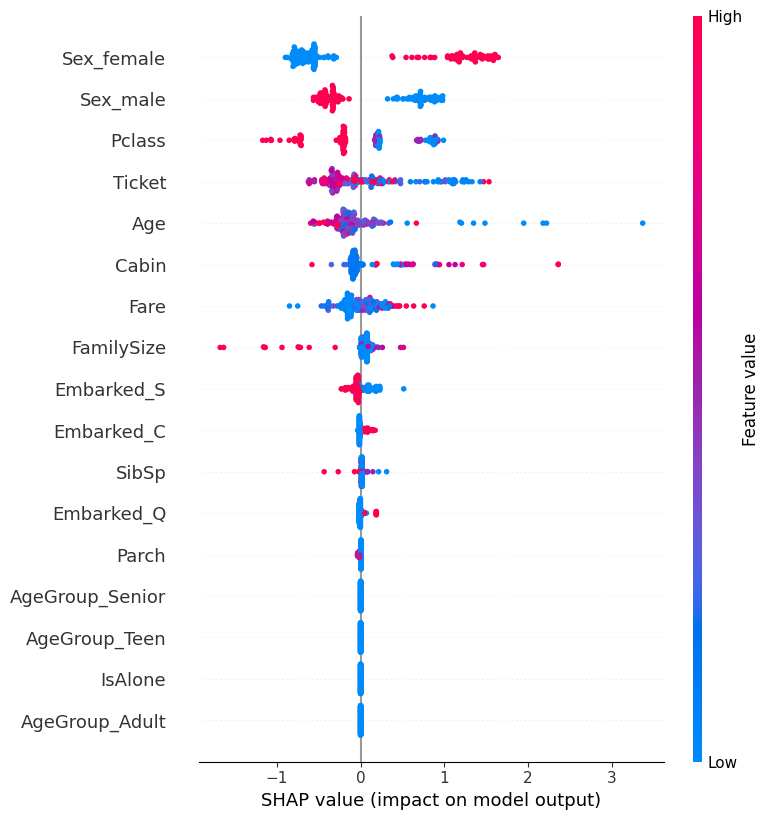

In [13]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test,feature_names=X.columns)

In [14]:
import joblib

joblib.dump(model, "test.pkl")

['test.pkl']

# Real Testing

In [15]:
import pandas as pd

data = {
    'PassengerId': list(range(1001, 1011)),
    'Pclass': [2,3,1,3,2,3,1,3,2,3],
    'Gender': ['female', 'male', 'female', 'male', 'female', 'male', 'female', 'male', 'female', 'male'],
    'Age': [28, 34, 45, 19, 38, 22, 29, 40, 33, 27],
    'SibSp': [0, 1, 0, 2, 1, 0, 0, 1, 0, 0],
    'Parch': [0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    'Ticket': ['345678', '456789', '123456', '789012', '234567', '345679', '456780', '567890', '678901', '789013'],
    'Fare': [15.5, 8.75, 52.0, 18.0, 21.3, 7.9, 110.5, 15.0, 25.0, 8.05],
    'Cabin': ['B12', '', 'C22', '', 'D5', '', 'E12', '', '', ''],
    'Embarked': ['S', 'Q', 'C', 'S', 'S', 'Q', 'C', 'S', 'S', 'Q'],
    'Degree': ['Master', 'Bachelor', 'PhD', '', 'Bachelor', '', 'Master', 'Bachelor', '', '']
}

test_df_new = pd.DataFrame(data)

test_df_new.to_csv('titanic_test_new_PID1001.csv', index=False)
print("New test dataset saved as 'titanic_test_new_PID1001.csv'")


New test dataset saved as 'titanic_test_new_PID1001.csv'


In [16]:
test_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10 non-null     int64  
 1   Pclass       10 non-null     int64  
 2   Gender       10 non-null     object 
 3   Age          10 non-null     int64  
 4   SibSp        10 non-null     int64  
 5   Parch        10 non-null     int64  
 6   Ticket       10 non-null     object 
 7   Fare         10 non-null     float64
 8   Cabin        10 non-null     object 
 9   Embarked     10 non-null     object 
 10  Degree       10 non-null     object 
dtypes: float64(1), int64(5), object(5)
memory usage: 1012.0+ bytes


In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

class DataPreprocessing:
    def __init__(self, df):
        self.df = df.copy() 
        self.encoder = LabelEncoder()
        self.scaler = StandardScaler()

    def tozala(self):
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if self.df[col].dtype == 'object':
                    self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
                else:
                    self.df[col] = self.df[col].fillna(self.df[col].mean())
        return self

    def encodla(self):
        for col in self.df.columns:
            if self.df[col].dtype == 'object':
                if self.df[col].nunique() <= 6:
                    dummies = pd.get_dummies(self.df[col], prefix=col, dtype=int)
                    self.df = pd.concat([self.df.drop(columns=[col]), dummies], axis=1)
                else:
                    self.df[col] = self.encoder.fit_transform(self.df[col])
        return self

    def scaling_qil(self):
        numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns
        self.df[numeric_cols] = self.scaler.fit_transform(self.df[numeric_cols])
        return self
     
   

    def get_df(self):
        return self.df


In [18]:
tayyorla=DataPreprocessing(test_df_new)
test_df_new=tayyorla.tozala().encodla().scaling_qil().get_df()

In [19]:
test_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      10 non-null     float64
 1   Pclass           10 non-null     float64
 2   Age              10 non-null     float64
 3   SibSp            10 non-null     float64
 4   Parch            10 non-null     float64
 5   Ticket           10 non-null     float64
 6   Fare             10 non-null     float64
 7   Gender_female    10 non-null     float64
 8   Gender_male      10 non-null     float64
 9   Cabin_           10 non-null     float64
 10  Cabin_B12        10 non-null     float64
 11  Cabin_C22        10 non-null     float64
 12  Cabin_D5         10 non-null     float64
 13  Cabin_E12        10 non-null     float64
 14  Embarked_C       10 non-null     float64
 15  Embarked_Q       10 non-null     float64
 16  Embarked_S       10 non-null     float64
 17  Degree_          10

In [20]:
test_df_new = test_df_new.rename(columns={'Cabin_': 'Cabin'})

In [21]:
test_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      10 non-null     float64
 1   Pclass           10 non-null     float64
 2   Age              10 non-null     float64
 3   SibSp            10 non-null     float64
 4   Parch            10 non-null     float64
 5   Ticket           10 non-null     float64
 6   Fare             10 non-null     float64
 7   Gender_female    10 non-null     float64
 8   Gender_male      10 non-null     float64
 9   Cabin            10 non-null     float64
 10  Cabin_B12        10 non-null     float64
 11  Cabin_C22        10 non-null     float64
 12  Cabin_D5         10 non-null     float64
 13  Cabin_E12        10 non-null     float64
 14  Embarked_C       10 non-null     float64
 15  Embarked_Q       10 non-null     float64
 16  Embarked_S       10 non-null     float64
 17  Degree_          10

In [22]:
test_df_new['FamilySize'] = test_df_new['SibSp'] + test_df_new['Parch'] + 1
test_df_new['IsAlone'] = (test_df_new['FamilySize'] == 1).astype(int)
test_df_new['AgeGroup'] = pd.cut(
    test_df_new['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
test_df_new = pd.get_dummies(test_df_new, columns=['AgeGroup'], drop_first=True)

In [23]:
test_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      10 non-null     float64
 1   Pclass           10 non-null     float64
 2   Age              10 non-null     float64
 3   SibSp            10 non-null     float64
 4   Parch            10 non-null     float64
 5   Ticket           10 non-null     float64
 6   Fare             10 non-null     float64
 7   Gender_female    10 non-null     float64
 8   Gender_male      10 non-null     float64
 9   Cabin            10 non-null     float64
 10  Cabin_B12        10 non-null     float64
 11  Cabin_C22        10 non-null     float64
 12  Cabin_D5         10 non-null     float64
 13  Cabin_E12        10 non-null     float64
 14  Embarked_C       10 non-null     float64
 15  Embarked_Q       10 non-null     float64
 16  Embarked_S       10 non-null     float64
 17  Degree_          10

In [24]:
feature_columns = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin',
    'Gender_female', 'Gender_male',
    'Embarked_C', 'Embarked_Q', 'Embarked_S',
    'Degree_Bachelor', 'Degree_Master', 'Degree_PhD',
    'FamilySize', 'IsAlone',
    'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Senior'
]

In [25]:
X_test = test_df_new[feature_columns]

In [26]:
X_test

,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Gender_female,Gender_male,Embarked_C,Embarked_Q,Embarked_S,Degree_Bachelor,Degree_Master,Degree_PhD,FamilySize,IsAlone,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,-0.384111,-0.455468,-0.745356,-0.5,-0.870388,-0.422546,-1.224745,1.0,-1.0,-0.5,-0.654654,1.0,-0.654654,2.0,-0.333333,-0.245356,0,False,False,False
1,0.896258,0.325334,0.745356,-0.5,0.174078,-0.647128,0.816497,-1.0,1.0,-0.5,1.527525,-1.0,1.527525,-0.5,-0.333333,1.245356,0,False,False,False
2,-1.664479,1.756806,-0.745356,-0.5,-1.566699,0.791858,-1.224745,1.0,-1.0,2.0,-0.654654,-1.0,-0.654654,-0.5,3.000000,-0.245356,0,False,False,False
3,0.896258,-1.626672,2.236068,2.0,1.218544,-0.339368,0.816497,-1.0,1.0,-0.5,-0.654654,1.0,-0.654654,-0.5,-0.333333,5.236068,0,False,False,False
4,-0.384111,0.845870,0.745356,-0.5,-1.218544,-0.229572,-1.224745,1.0,-1.0,-0.5,-0.654654,1.0,1.527525,-0.5,-0.333333,1.245356,0,False,False,False
5,0.896258,-1.236271,-0.745356,-0.5,-0.522233,-0.675408,0.816497,-1.0,1.0,-0.5,1.527525,-1.0,-0.654654,-0.5,-0.333333,-0.245356,0,False,False,False
6,-1.664479,-0.325334,-0.745356,-0.5,-0.174078,2.738232,-1.224745,1.0,-1.0,2.0,-0.654654,-1.0,-0.654654,2.0,-0.333333,-0.245356,0,False,False,False
7,0.896258,1.106137,0.745356,2.0,0.522233,-0.439182,0.816497,-1.0,1.0,-0.5,-0.654654,1.0,1.527525,-0.5,-0.333333,3.745356,0,False,False,False
8,-0.384111,0.195201,-0.745356,-0.5,0.870388,-0.106468,0.816497,1.0,-1.0,-0.5,-0.654654,1.0,-0.654654,-0.5,-0.333333,-0.245356,0,False,False,False
9,0.896258,-0.585602,-0.745356,-0.5,1.566699,-0.670418,0.816497,-1.0,1.0,-0.5,1.527525,-1.0,-0.654654,-0.5,-0.333333,-0.245356,0,False,False,False


In [27]:
model = joblib.load("test.pkl")

In [30]:
# Combine train and test to ensure same columns
combined = pd.concat([X_train, X_test], axis=0)

# One-hot encoding
combined_encoded = pd.get_dummies(combined, drop_first=True)

# Split back
X_train_encoded = combined_encoded.iloc[:len(X_train), :]
X_test_encoded = combined_encoded.iloc[len(X_train):, :]


In [32]:
from sklearn.impute import SimpleImputer

# Imputer yaratamiz
imputer = SimpleImputer(strategy='mean')  # yoki strategy='most_frequent' kategorylar uchun

# X_train va X_test uchun
X_train_encoded = imputer.fit_transform(X_train_encoded)
X_test_encoded = imputer.transform(X_test_encoded)


c:\Users\Rasulbek_Ruzmetov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Gender_female' 'Gender_male' 'Degree_Bachelor' 'Degree_Master'
 'Degree_PhD']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Rasulbek_Ruzmetov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['Gender_female' 'Gender_male' 'Degree_Bachelor' 'Degree_Master'
 'Degree_PhD']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [33]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier()
model.fit(X_train_encoded, y_train)
predictions = model.predict(X_test_encoded)


In [35]:
# 1. Birlashtirib olaylik
X_all = pd.concat([X_train, X_test], axis=0)

# 2. One-hot encoding
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

# 3. Bo‘lib olish
X_train_encoded = X_all_encoded.iloc[:len(X_train), :]
X_test_encoded = X_all_encoded.iloc[len(X_train):, :]


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import pandas as pd

# Titanic dataset
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Tozalash
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Tanlash
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Train-test bo‘linadi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Birlashtirib get_dummies
X_all = pd.concat([X_train, X_test], axis=0)
X_all_encoded = pd.get_dummies(X_all, drop_first=True)
X_train_encoded = X_all_encoded.iloc[:len(X_train), :]
X_test_encoded = X_all_encoded.iloc[len(X_train):, :]

# Model
model = HistGradientBoostingClassifier()
model.fit(X_train_encoded, y_train)
predictions = model.predict(X_test_encoded)


C:\Users\Rasulbek_Ruzmetov\AppData\Local\Temp\ipykernel_19192\1814601260.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Rasulbek_Ruzmetov\AppData\Local\Temp\ipykernel_19192\1814601260.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [40]:
model.fit(X_train_encoded, y_train)
predictions = model.predict(X_test_encoded)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier


df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")


df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_all = pd.concat([X_train, X_test], axis=0)
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

X_train_encoded = X_all_encoded.iloc[:len(X_train), :]
X_test_encoded = X_all_encoded.iloc[len(X_train):, :]


model = HistGradientBoostingClassifier()
model.fit(X_train_encoded, y_train)


predictions = model.predict(X_test_encoded)


C:\Users\Rasulbek_Ruzmetov\AppData\Local\Temp\ipykernel_19192\568574392.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Rasulbek_Ruzmetov\AppData\Local\Temp\ipykernel_19192\568574392.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [43]:
predictions

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

# Pipeline

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [46]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [47]:
df=df.dropna(subset=['Survived'])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [49]:
x = df.drop(columns=['Survived', 'PassengerId'])
y=df['Survived']

In [50]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

In [51]:
num_cols

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [52]:
cat_cols

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [53]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [54]:
num_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [55]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [56]:
cat_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [57]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [58]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['Name', 'Sex', 'Ticket', 'Cabin',
                                  'Embarked'])])

In [59]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [60]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Name', 'Sex', 'Ticket',
                                                   'Cabin', 'Embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer

# Ma'lumot yuklash
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Foydalaniladigan ustunlar
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Train/test bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Transformerlar
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingClassifier())
])

# Fit qilish
pipeline.fit(X_train, y_train)

# Bashorat
predictions = pipeline.predict(X_test)


In [63]:
pipeline.fit(x, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', HistGradientBoostingClassifier())])

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8268156424581006


In [66]:
joblib.dump(pipeline, 'Pipeline_Model.pkl')

['Pipeline_Model.pkl']